In [1]:
import os
import sys

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from project.model.coherence_from_data import auto_coherence, show_coherence, coherence
from project.model.detection import show_photons, Spad23, Spad512, merge_photons
from project.model.sample import Alexa647
from project.model.setup import Setup, ScanningSetup, WidefieldSetup

import pickle
import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from abc import ABC, abstractmethod


np.random.seed(42)

# Set the global font to be DejaVu Sans, size 10 (or any other font you prefer)
plt.rcParams['font.family'] = 'serif'  # Options: 'serif', 'sans-serif', 'monospace'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']

# Font sizes for different elements
plt.rcParams['font.size'] = 12          # Base font size
plt.rcParams['axes.titlesize'] = 14     # Title font size
plt.rcParams['axes.labelsize'] = 12     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 10    # X tick label font size
plt.rcParams['ytick.labelsize'] = 10    # Y tick label font size
plt.rcParams['legend.fontsize'] = 10    # Legend font size
plt.rcParams['figure.titlesize'] = 16   # Figure title font size

# Font weight
plt.rcParams['axes.labelweight'] = 'normal'  # Options: 'normal', 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Figure and axes settings
plt.rcParams['figure.figsize'] = (8, 6)     # Default figure size (width, height)
plt.rcParams['figure.dpi'] = 100            # Figure resolution
plt.rcParams['savefig.dpi'] = 300           # Saved figure resolution (high quality for thesis)
plt.rcParams['savefig.format'] = 'pdf'      # Default save format (PDF is vector format, good for thesis)
plt.rcParams['savefig.bbox'] = 'tight'      # Remove extra whitespace when saving

# Line and marker settings
plt.rcParams['lines.linewidth'] = 2.0       # Default line width
plt.rcParams['lines.markersize'] = 6        # Default marker size
plt.rcParams['lines.markeredgewidth'] = 1.0 # Marker edge width

# Axes settings
plt.rcParams['axes.linewidth'] = 1.2        # Axes border line width
plt.rcParams['axes.spines.top'] = False     # Remove top spine
plt.rcParams['axes.spines.right'] = False   # Remove right spine
plt.rcParams['axes.grid'] = False            # Enable grid by default
plt.rcParams['grid.alpha'] = 0.3            # Grid transparency
plt.rcParams['grid.linewidth'] = 0.8        # Grid line width

# Tick settings
plt.rcParams['xtick.major.size'] = 5        # X major tick size
plt.rcParams['xtick.minor.size'] = 3        # X minor tick size
plt.rcParams['ytick.major.size'] = 5        # Y major tick size
plt.rcParams['ytick.minor.size'] = 3        # Y minor tick size
plt.rcParams['xtick.major.width'] = 1.2     # X major tick width
plt.rcParams['xtick.minor.width'] = 0.8     # X minor tick width
plt.rcParams['ytick.major.width'] = 1.2     # Y major tick width
plt.rcParams['ytick.minor.width'] = 0.8     # Y minor tick width
plt.rcParams['xtick.direction'] = 'in'      # Tick direction: 'in', 'out', 'inout'
plt.rcParams['ytick.direction'] = 'in'

# Legend settings
plt.rcParams['legend.frameon'] = True       # Legend frame
plt.rcParams['legend.framealpha'] = 0.9     # Legend frame transparency
plt.rcParams['legend.fancybox'] = True      # Rounded corners for legend
plt.rcParams['legend.numpoints'] = 1        # Number of points in legend for line plots

# LaTeX settings (optional - for high-quality mathematical expressions)
plt.rcParams['text.usetex'] = False         # Set to True if you have LaTeX installed
plt.rcParams['mathtext.default'] = 'regular'  # Math font style

# Color settings - you can define a custom color palette
thesis_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=thesis_colors)

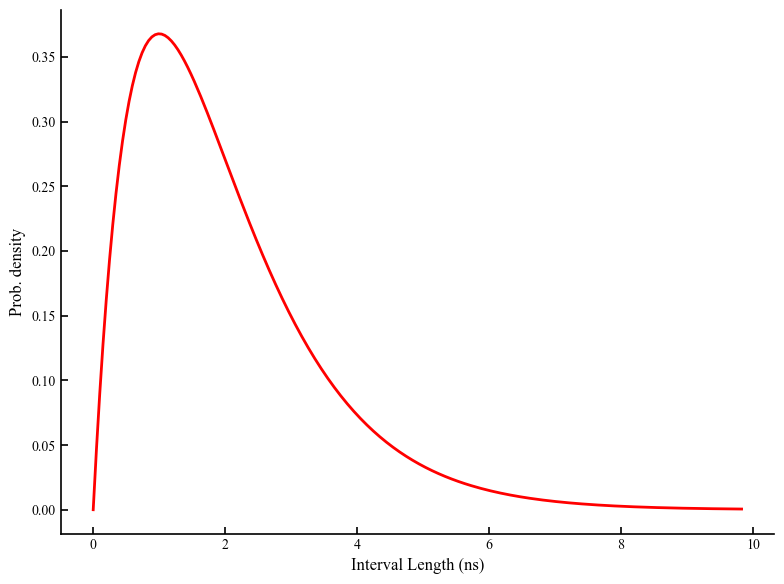

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Set random seed for reproducibility


# Parameters
k_ex = 1.0
k_em = 1.0
n_events = 5000

# Generate inter-arrival times (exponentially distributed)
intervals = np.random.exponential(1/k_ex, n_events) + np.random.exponential(1/k_em, n_events)

X = np.random.exponential(1/k_ex, n_events)
Y = np.random.exponential(1/k_em, n_events)
Z = X + Y
# Generate cumulative arrival times
arrival_times = np.cumsum(intervals)

# Plot histogram of intervals
plt.figure()
#plt.hist(intervals, bins=100, density=True, alpha=0.7, color='skyblue', edgecolor='black')

# Overlay theoretical exponential distribution
x = np.linspace(0, max(intervals), 100)
theoretical1 = gamma.pdf(x, a=2, scale=k_ex + k_em)
theoretical2 = (k_ex+k_em)**2 *x * np.exp(-(k_ex+k_em) * x)

def hypoexp_pdf(z, a, b):
    if abs(a - b) < 1e-10:  # Equal rates case (Gamma)
        return a**2 * z * np.exp(-a * z)
    else:  # Different rates case
        return (a * b / (b - a)) * (np.exp(-a * z) - np.exp(-b * z))

# Plot theoretical curve
z_theory = np.linspace(0, max(Z), 200)
theoretical = [hypoexp_pdf(z, k_ex, k_em) for z in z_theory]
plt.plot(z_theory, theoretical, 'r-', linewidth=2, 
         label=f'Theoretical (a={k_ex}, b={k_em})')

#plt.plot(x, theoretical1, 'r-', linewidth=2, label=f'Theoretical Gam({k_ex+k_em})')
#plt.plot(x, theoretical2, 'r-', linewidth=2, label=f'Theoretical Gam({k_ex+k_em})')
#plt.plot(x, 5*theoretical1*theoretical2, 'r-', linewidth=2, label=f'Theoretical Gam({k_ex+k_em})')


plt.xlabel('Interval Length (ns)')
plt.ylabel('Prob. density')
#increase textsize of plot


plt.tight_layout()
plt.show()

Plot showing basic antibunching effect

Starting scanning experiment: 0.5×0.5 μm area...
Failed to generate emitters with bounds. Trying without bounds.
Generated 1 emitters
Running scan...
Starting scan of 0.5×0.5 µm² area with 1×1 positions
Step size: 0.500 × 0.500 µm
ISM processing enabled with alpha=0.5
Progress: 100.0% (1/1), Est. remaining time: 0.0s
Scan completed in 0.48 seconds
Calculation summary: 1 successful calculations, 0 failed calculations, 0 skipped due to low photon count (<10)
NR EMITTERS MAP
[[1.07]]
Performing ISM processing...
ISM processing completed in 8.29 seconds
Fitted k: 1.02114055334664


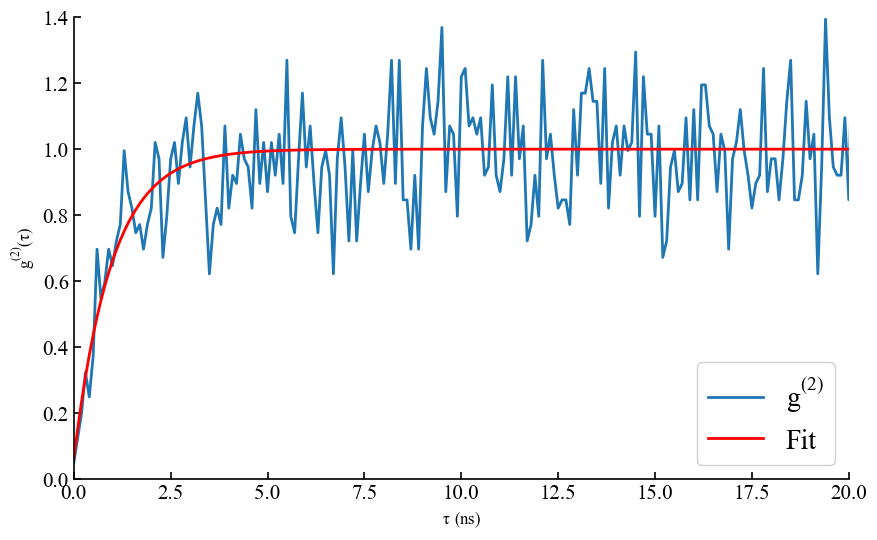

In [16]:
from project.simulations.run_scanning_experiment import run_scanning_experiment
from project.model.coherence_from_data import fit_coherence_function
setup, scan_data, _, _, _ = run_scanning_experiment(
    positions = (1,1),
    laser_power= 100E3,
    area_size = (0.5,0.5),
    emitter_density = 5, show_plots=False, save_data=False)

g2 = setup.scan_data['g2_data'][(0,0)][0]
bins = setup.scan_data['g2_data'][(0,0)][1]
fit,popt,pcov = fit_coherence_function(bins, g2, method='with_k', initial_guess = [3,2])

#Plot
plt.figure(figsize=(10, 6))
plt.plot(bins, g2, label=r"$g^{(2)}$")
plt.xlim(0, 20)
plt.ylim(0, 1.4)
#plot coherence curve
plt.plot(bins,fit, label='Fit', color='red')
plt.xlabel(r"$\tau \  (ns)$")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.legend(fontsize=20)